# 03 — Preparación Final del Dataset para Modelado

Este notebook transforma el dataset limpio (salida de `01_limpieza.ipynb`) en el dataset final listo para entrenar los modelos predictivos. Cubre cuatro bloques:

1. **Ingeniería de características** — variables derivadas espaciotemporales
2. **Variable objetivo** — puntaje de gravedad compuesto (4 factores)
3. **Balanceo de clases** — corrección de distribución desigual entre niveles de gravedad
4. **Partición y exportación** — split estratificado 80/20 y guardado de archivos finales

In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# =============================================================
# RUTAS
# =============================================================
ARCHIVO_LIMPIO = r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_detenidosaprehendidos_guayaquil_2019_2025_con_delitos_y_tipo_dato.csv"

# Salidas
RUTA_BASE = r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV"
ARCHIVO_FINAL   = RUTA_BASE + r"\mdi_dataset_final.csv"
ARCHIVO_TRAIN   = RUTA_BASE + r"\mdi_train.csv"
ARCHIVO_TEST    = RUTA_BASE + r"\mdi_test.csv"
ARCHIVO_BALANCE = RUTA_BASE + r"\mdi_train_balanceado.csv"

---
## 1. Carga del dataset limpio

In [4]:
df = pd.read_csv(
    ARCHIVO_LIMPIO,
    sep=";",
    encoding="utf-8-sig",
    keep_default_na=False,
    low_memory=False
)

# Conversiones base (igual que en el EDA)
for col in ["latitud", "longitud"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

df["fecha_dt"] = pd.to_datetime(
    df["fecha_detencion_aprehension"], dayfirst=True, errors="coerce"
)

print(f"Filas cargadas : {len(df):,}")
print(f"Columnas       : {len(df.columns)}")
df.head(3)

Filas cargadas : 76,860
Columnas       : 40


,Unnamed: 0,codigo_iccs,delitos,tipo_dato,tipo,estado civil,estatus_migratorio,edad,sexo,genero,...,nombre_provincia,codigo_canton,nombre_canton,codigo_parroquia,nombre_parroquia,presunta_infraccion,latitud,longitud,flag_coord,fecha_dt
0,,20510.00,DELITOS CONTRA EL DERECHO A LA PROPIEDAD,SINTETICO,DETENIDO,DIVORCIADO/A,SE_DESCONOCE,42,HOMBRE,MASCULINO,...,GUAYAS,901,GUAYAQUIL,90150,GUAYAQUIL-MUCHO LOTE,BOLETAS,-2.090979,-79.921294,REAL,2025-12-31
1,,10102.01,DELITOS CONTRA LA INVIOLABILIDAD DE LA VIDA,ORIGINAL,APREHENDIDO,SOLTERO/A,REGULAR,22,HOMBRE,MASCULINO,...,GUAYAS,901,GUAYAQUIL,90150,GUAYAQUIL-BASTION POPULAR N2,DELITOS CONTRA LA INVIOLABILIDAD DE LA VIDA,-2.094478,-79.927189,REAL,2025-12-31
2,,10102.03,DELITOS CONTRA EL DERECHO A LA PROPIEDAD,SINTETICO,DETENIDO,SOLTERO/A,NO_APLICA,40,HOMBRE,NO_APLICA,...,GUAYAS,901,GUAYAQUIL,90158,TENGUEL,BOLETAS,-2.996068,-79.792878,REAL,2025-12-31


---
## 2. Ingeniería de características

Se generan variables derivadas temporales, espaciales y de contexto que enriquecen la representación del dataset para los modelos.

### 2.1 Variables temporales

In [5]:
# ── Temporales básicas ─────────────────────────────────────────
df["anio"]       = df["fecha_dt"].dt.year
df["mes"]        = df["fecha_dt"].dt.month
df["dia_semana"] = df["fecha_dt"].dt.dayofweek   # 0=lunes, 6=domingo
df["es_fin_de_semana"] = df["dia_semana"].isin([5, 6]).astype(int)

df["hora"] = pd.to_numeric(
    df["hora_detencion_aprehension"].astype(str).str.split(":").str[0],
    errors="coerce"
)

# ── Franja horaria (ajustada a los picos reales del EDA) ───────
# El análisis exploratorio confirmó dos picos de actividad:
# 11-12h (pico máximo) y 17-18h (segundo pico).
# La madrugada (0-8h) presenta la menor actividad registrada.
# Nota metodológica: estos patrones reflejan horarios de detención
# (actividad policial), no necesariamente ocurrencia real del delito.

def asignar_franja(hora):
    if pd.isna(hora):
        return "SIN_DATO"
    h = int(hora)
    if 9 <= h <= 13:
        return "PICO_MAÑANA"       # pico principal
    elif 14 <= h <= 19:
        return "PICO_TARDE"        # segundo pico
    elif 20 <= h <= 23:
        return "NOCHE"
    else:                           # 0-8h
        return "MADRUGADA"

df["franja_horaria"] = df["hora"].apply(asignar_franja)

print("Distribución de franjas horarias:")
print(df["franja_horaria"].value_counts())

Distribución de franjas horarias:
franja_horaria
PICO_TARDE     27032
PICO_MAÑANA    23194
MADRUGADA      14915
NOCHE          11719
Name: count, dtype: int64


### 2.2 Macro-categorías de lugar

El campo `tipo_lugar` tiene 65 categorías distintas. Se agrupa en 6 macro-categorías para reducir la dispersión y mejorar la capacidad generalizadora del modelo.

In [6]:
MAPA_LUGAR = {
    # ESPACIO PÚBLICO
    "ÁREAS DE ACCESO PÚBLICO": "ESPACIO_PUBLICO",
    "VÍA PÚBLICA":             "ESPACIO_PUBLICO",
    "ESPACIO PÚBLICO":         "ESPACIO_PUBLICO",
    "PARQUES":                 "ESPACIO_PUBLICO",
    "TROCHA":                  "ESPACIO_PUBLICO",
    "BOSQUES":                 "ESPACIO_PUBLICO",
    "RÍO":                     "ESPACIO_PUBLICO",
    "TERRENOS BALDIOS":        "ESPACIO_PUBLICO",
    "CANCHAS DE USO MULTIPLE": "ESPACIO_PUBLICO",
    "ESTADIOS":                "ESPACIO_PUBLICO",

    # ÁREA PRIVADA / VIVIENDA
    "ÁREA PRIVADA":            "VIVIENDA_PRIVADA",
    "VIVIENDA/ALOJAMIENTO":    "VIVIENDA_PRIVADA",
    "VIVIENDA PARTICULAR":     "VIVIENDA_PRIVADA",
    "ESPACIO PRIVADO":         "VIVIENDA_PRIVADA",
    "CONJUNTO HABITACIONAL":   "VIVIENDA_PRIVADA",
    "CASA DE LA VICTIMA":      "VIVIENDA_PRIVADA",
    "CASA DEL VICTIMARIO":     "VIVIENDA_PRIVADA",
    "CASA DE PROTECCIÓN":      "VIVIENDA_PRIVADA",

    # COMERCIO / SERVICIOS
    "ÁREAS DEDICADAS AL COMERCIO": "COMERCIO_SERVICIOS",
    "CENTROS COMERCIALES":         "COMERCIO_SERVICIOS",
    "ALMACENES":                   "COMERCIO_SERVICIOS",
    "RESTAURANTES":                "COMERCIO_SERVICIOS",
    "TIENDAS":                     "COMERCIO_SERVICIOS",
    "BARES":                       "COMERCIO_SERVICIOS",
    "NIGTH CLUBS":                 "COMERCIO_SERVICIOS",
    "CENTROS DE DIVERSIÓN":        "COMERCIO_SERVICIOS",
    "SALAS DE JUEGO":              "COMERCIO_SERVICIOS",
    "HELADERIA":                   "COMERCIO_SERVICIOS",
    "HELADERIAS":                  "COMERCIO_SERVICIOS",
    "GASOLINERAS":                 "COMERCIO_SERVICIOS",
    "PARQUEADEROS":                "COMERCIO_SERVICIOS",
    "HOTELES":                     "COMERCIO_SERVICIOS",
    "BODEGAS":                     "COMERCIO_SERVICIOS",
    "CACHINERIAS":                 "COMERCIO_SERVICIOS",
    "MERCADOS":                    "COMERCIO_SERVICIOS",
    "FERIA DE VEHICULOS":          "COMERCIO_SERVICIOS",
    "SERVICIOS BASICOS":           "COMERCIO_SERVICIOS",

    # TRANSPORTE
    "TRANSPORTE":                       "TRANSPORTE",
    "TRANSPORTE PÚBLICO":               "TRANSPORTE",
    "AUTOBUS":                          "TRANSPORTE",
    "TERMINALES TERRESTRES":            "TRANSPORTE",
    "AEROPUERTOS":                      "TRANSPORTE",
    "INTERIOR DEL VEHICULO PARTICULAR": "TRANSPORTE",
    "PUERTOS":                          "TRANSPORTE",
    "CORREOS":                          "TRANSPORTE",

    # INSTITUCIONES
    "ENTIDADES PUBLICAS":         "INSTITUCION",
    "INSTITUCIONES EDUCATIVAS":   "INSTITUCION",
    "INSTITUCIONES DE SALUD":     "INSTITUCION",
    "CENTROS DE SALUD":           "INSTITUCION",
    "HOSPITALES":                 "INSTITUCION",
    "MINISTERIOS":                "INSTITUCION",
    "FISCALIA":                   "INSTITUCION",
    "JUZGADOS":                   "INSTITUCION",
    "ESCUELAS":                   "INSTITUCION",
    "COLEGIOS":                   "INSTITUCION",
    "CONSEJO DE LA JUDICATURA":   "INSTITUCION",
    "ENTIDADES FINANCIERAS":      "INSTITUCION",
    "BANCOS":                     "INSTITUCION",
    "ORGANISMOS INTERNACIONALES": "INSTITUCION",
    "INDUSTRIAS":                 "INSTITUCION",
    "UNIDAD FUERZAS ARMADAS":     "INSTITUCION",

    # CENTROS DE PRIVACIÓN DE LIBERTAD
    "CENTRO DE REHABILITACIÓN SOCIAL (CRS)":           "CPL",
    "CENTROS DE REHABILITACIÓN SOCIAL":                "CPL",
    "CENTRO DE PRIVACIÓN PROVISIONAL DE LIBERTAD (CPPL)": "CPL",
    "CENTRO DE ADOLESCENTES INFRACTORES (CAI)":        "CPL",
    "UNIDADES DE REACCIÓN Y EMERGENCIA":               "CPL",
    "UNIDADES DE ASEGURAMIENTO TRANSITORIO (UAT)":     "CPL",
    "UNIDAD POLICIAL":                                 "CPL",
    "CENTRO DE DETENCION PROVISIONAL":                 "CPL",
    "ZONA DE INSPECCIÓN":                              "CPL",
}

df["macro_lugar"] = df["tipo_lugar"].map(MAPA_LUGAR).fillna("OTRO")

print("Distribución macro-categorías de lugar:")
print(df["macro_lugar"].value_counts())

Distribución macro-categorías de lugar:
macro_lugar
ESPACIO_PUBLICO       52719
VIVIENDA_PRIVADA      17901
CPL                    2180
COMERCIO_SERVICIOS     1352
INSTITUCION            1335
TRANSPORTE             1072
OTRO                    301
Name: count, dtype: int64


### 2.3 Frecuencia histórica por subcircuito

Se calcula el número total de incidentes registrados por subcircuito en todo el período 2019–2025 y se discretiza en cuartiles (0–3). Esta variable captura la carga histórica de actividad delictiva por zona geográfica.

In [7]:
# Frecuencia absoluta por subcircuito
freq_sub = df.groupby("codigo_subcircuito").size().rename("freq_subcircuito")
df = df.join(freq_sub, on="codigo_subcircuito")

# Discretizar en cuartiles (0=bajo, 3=muy alto)
df["freq_sub_cuartil"] = pd.qcut(
    df["freq_subcircuito"],
    q=4,
    labels=[0, 1, 2, 3],
    duplicates="drop"
).astype(int)

print("Distribución de cuartiles de frecuencia por subcircuito:")
print(df["freq_sub_cuartil"].value_counts().sort_index())
print(f"\nSubcircuito con más incidentes: {freq_sub.idxmax()} ({freq_sub.max():,})")
print(f"Subcircuito con menos incidentes: {freq_sub.idxmin()} ({freq_sub.min():,})")

Distribución de cuartiles de frecuencia por subcircuito:
freq_sub_cuartil
0    19614
1    18998
2    19567
3    18681
Name: count, dtype: int64

Subcircuito con más incidentes: 09D07C07S02 (2,567)
Subcircuito con menos incidentes: 09D08C04S04 (2)


---
## 3. Variable objetivo: puntaje de gravedad

La variable objetivo es un puntaje compuesto que pondera cuatro dimensiones del registro:

| Factor | Rango | Descripción |
|--------|-------|-------------|
| Tipo de delito | 1–4 | Severidad según clasificación COIP/ICCS |
| Uso de arma | 0–3 | Presencia y tipo de arma en el evento |
| Frecuencia por zona | 0–3 | Cuartil histórico del subcircuito |
| Franja horaria | 0–2 | Basado en los picos reales del EDA |

**Puntaje total: 0–12** → discretizado en 4 clases de gravedad.

In [8]:
# ── FACTOR 1: Tipo de delito (0–4) ────────────────────────────
# Pesos definidos según la naturaleza del delito:
# - Delitos con alto impacto social y físico directo: 4
# - Delitos patrimoniales y de tráfico de sustancias: 3
# - Delitos administrativos y contravenciones: 1

PESO_DELITO = {
    "DELITOS CONTRA LA SEGURIDAD PÚBLICA":                                      4,
    "TERRORISMO Y SU FINANCIACIÓN":                                             4,
    "DELITOS CONTRA LA INTEGRIDAD SEXUAL Y REPRODUCTIVA":                       4,
    "DELITOS POR LA PRODUCCIÓN O TRÁFICO ILÍCITO DE SUSTANCIAS CATALOGADAS SUJETAS A FISCALIZACIÓN": 3,
    "DELITOS CONTRA EL DERECHO A LA PROPIEDAD":                                 3,
    "DELITOS DE VIOLENCIA CONTRA LA MUJER O MIEMBROS DEL NÚCLEO FAMILIAR":      3,
    "CONTRAVENCIÓN DE VIOLENCIA CONTRA LA MUJER O MIEMBROS DEL NÚCLEO FAMILIAR": 2,
    "DELITOS CONTRA LA EFICIENCIA DE LA ADMINISTRACIÓN PÚBLICA":                1,
    "DELITOS CONTRA LA TUTELA JUDICIAL EFECTIVA":                               1,
    "CONTRAVENCIONES":                                                           1,
}

df["peso_delito"] = df["delitos"].map(PESO_DELITO).fillna(1)

print("Factor 1 — Tipo de delito:")
print(df["peso_delito"].value_counts().sort_index())

Factor 1 — Tipo de delito:
peso_delito
1.0    18941
2.0     2554
3.0    42685
4.0    12680
Name: count, dtype: int64


In [9]:
# ── FACTOR 2: Uso de arma (0–3) ───────────────────────────────
PESO_ARMA = {
    "ARMAS DE FUEGO":                         3,
    "ARMAS BLANCAS (OBJETO CORTANTE O PUNZANTE)": 2,
    "SIN_DATO":                               1,  # información no registrada: incertidumbre media
    "NINGUNA":                                0,
}

df["peso_arma"] = df["tipo_arma"].map(PESO_ARMA).fillna(1)

print("Factor 2 — Tipo de arma:")
print(df["peso_arma"].value_counts().sort_index())

Factor 2 — Tipo de arma:
peso_arma
0    55015
1    11988
2     2080
3     7777
Name: count, dtype: int64


In [10]:
# ── FACTOR 3: Frecuencia histórica por subcircuito (0–3) ──────
# Ya calculada: freq_sub_cuartil
df["peso_zona"] = df["freq_sub_cuartil"]

# ── FACTOR 4: Franja horaria (0–2) ────────────────────────────
# Basado en los picos reales del EDA: 9-13h y 14-19h son las
# franjas con mayor concentración de detenciones registradas.
# IMPORTANTE: este patrón refleja operatividad policial, no
# necesariamente la ocurrencia real del delito — se documenta
# como limitación metodológica en el artículo.

PESO_FRANJA = {
    "PICO_MAÑANA": 2,
    "PICO_TARDE":  2,
    "NOCHE":       1,
    "MADRUGADA":   0,
    "SIN_DATO":    1,
}

df["peso_franja"] = df["franja_horaria"].map(PESO_FRANJA).fillna(1)

print("Factor 4 — Franja horaria:")
print(df["peso_franja"].value_counts().sort_index())

Factor 4 — Franja horaria:
peso_franja
0    14915
1    11719
2    50226
Name: count, dtype: int64


In [11]:
# ── PUNTAJE TOTAL Y CLASES DE GRAVEDAD ────────────────────────
df["puntaje_gravedad"] = (
    df["peso_delito"] +
    df["peso_arma"]   +
    df["peso_zona"]   +
    df["peso_franja"]
)

# Discretización en 4 clases (rango total: 0–12)
bins   = [-1, 3, 6, 9, 12]
labels = ["BAJA", "MEDIA", "ALTA", "CRITICA"]

df["gravedad"] = pd.cut(
    df["puntaje_gravedad"],
    bins=bins,
    labels=labels
)

print("\nDistribución del puntaje de gravedad:")
print(df["puntaje_gravedad"].describe())
print("\nDistribución de clases de gravedad:")
print(df["gravedad"].value_counts())
print(f"\nPorcentaje por clase:")
print((df["gravedad"].value_counts() / len(df) * 100).round(1))


Distribución del puntaje de gravedad:
count    76860.000000
mean         6.097437
std          2.007264
min          1.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         12.000000
Name: puntaje_gravedad, dtype: float64

Distribución de clases de gravedad:
gravedad
MEDIA      37858
ALTA       27494
BAJA        7641
CRITICA     3867
Name: count, dtype: int64

Porcentaje por clase:
gravedad
MEDIA      49.3
ALTA       35.8
BAJA        9.9
CRITICA     5.0
Name: count, dtype: float64


### 3.1 Visualización de clases por año

Se muestra la distribución de niveles de gravedad separada por año, para identificar si existe evolución temporal en la composición de clases.

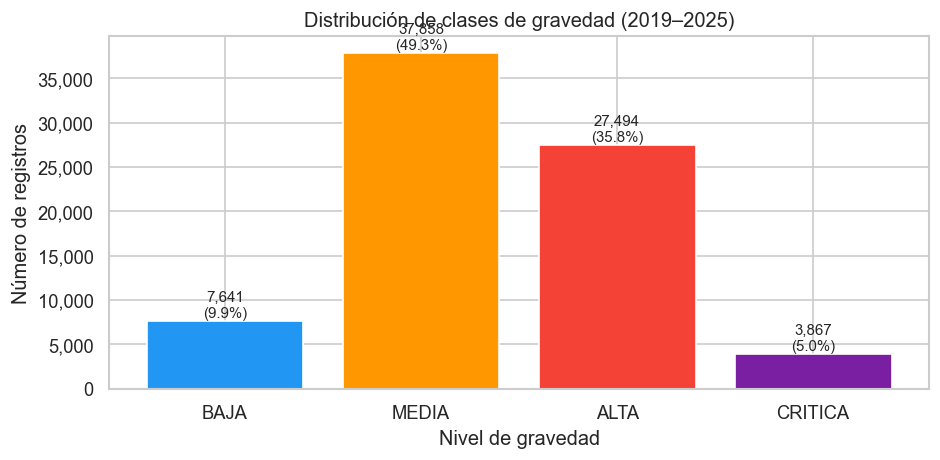

In [12]:
# ── Distribución general de clases ────────────────────────────
orden_clases   = ["BAJA", "MEDIA", "ALTA", "CRITICA"]
colores_clases = ["#2196F3", "#FF9800", "#F44336", "#7B1FA2"]

conteo = df["gravedad"].value_counts()[orden_clases]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(conteo.index, conteo.values, color=colores_clases)
ax.set_title("Distribución de clases de gravedad (2019–2025)")
ax.set_xlabel("Nivel de gravedad")
ax.set_ylabel("Número de registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

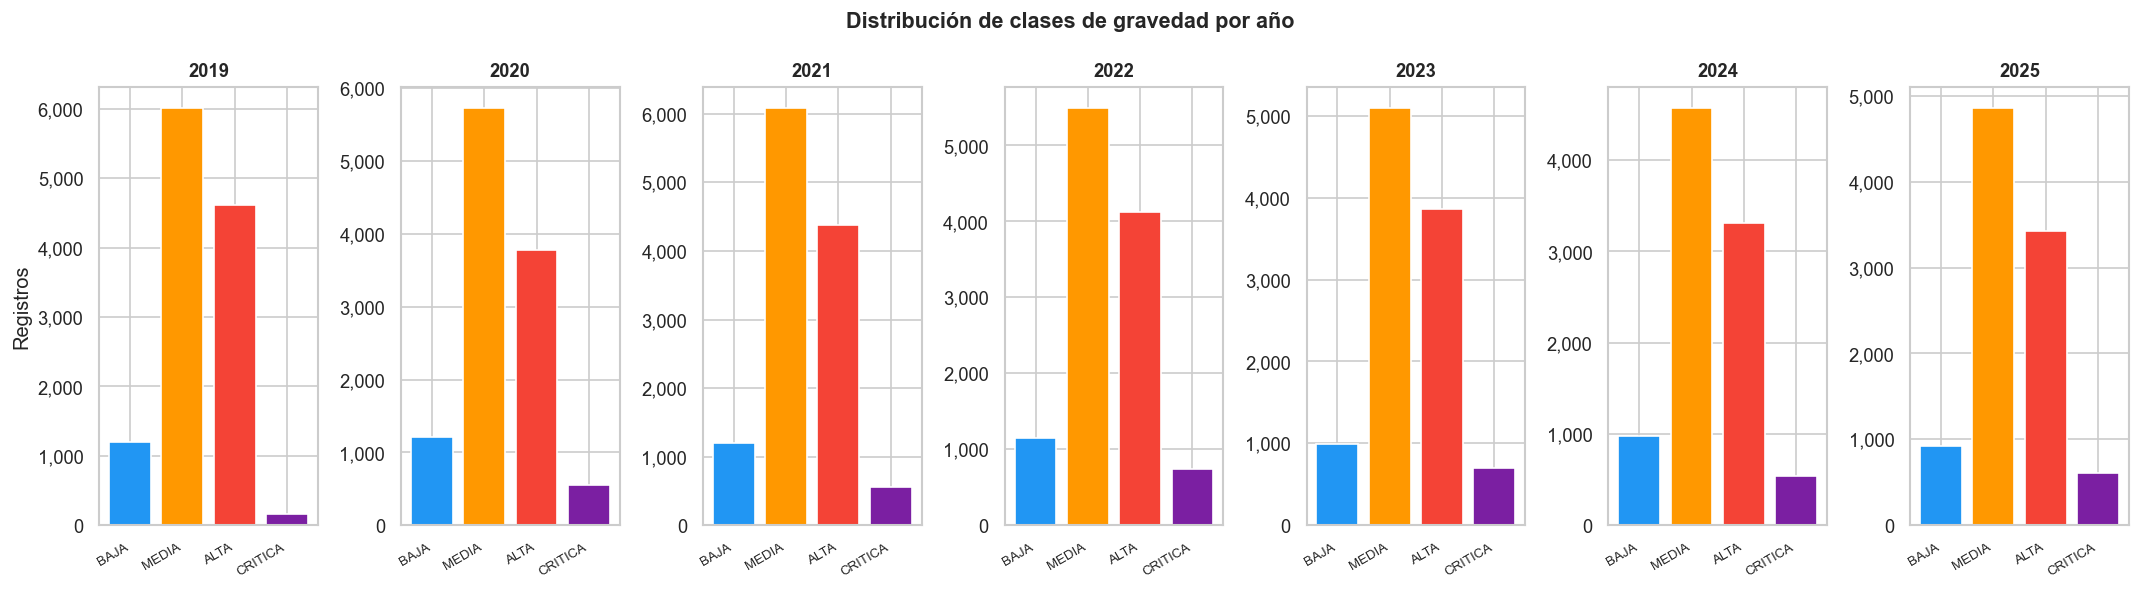

In [13]:
# ── Distribución de clases por año (pedido del tutor) ─────────
por_anio_clase = (
    df.groupby(["anio", "gravedad"])
    .size()
    .reset_index(name="total")
)

fig, axes = plt.subplots(1, len(df["anio"].dropna().unique()), figsize=(18, 5), sharey=False)

for ax, anio in zip(axes, sorted(df["anio"].dropna().unique())):
    datos = por_anio_clase[por_anio_clase["anio"] == anio].set_index("gravedad")
    datos = datos.reindex(orden_clases).fillna(0)
    ax.bar(datos.index, datos["total"], color=colores_clases)
    ax.set_title(str(int(anio)), fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks(range(4))
    ax.set_xticklabels(orden_clases, rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    if ax == axes[0]:
        ax.set_ylabel("Registros")

fig.suptitle("Distribución de clases de gravedad por año", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

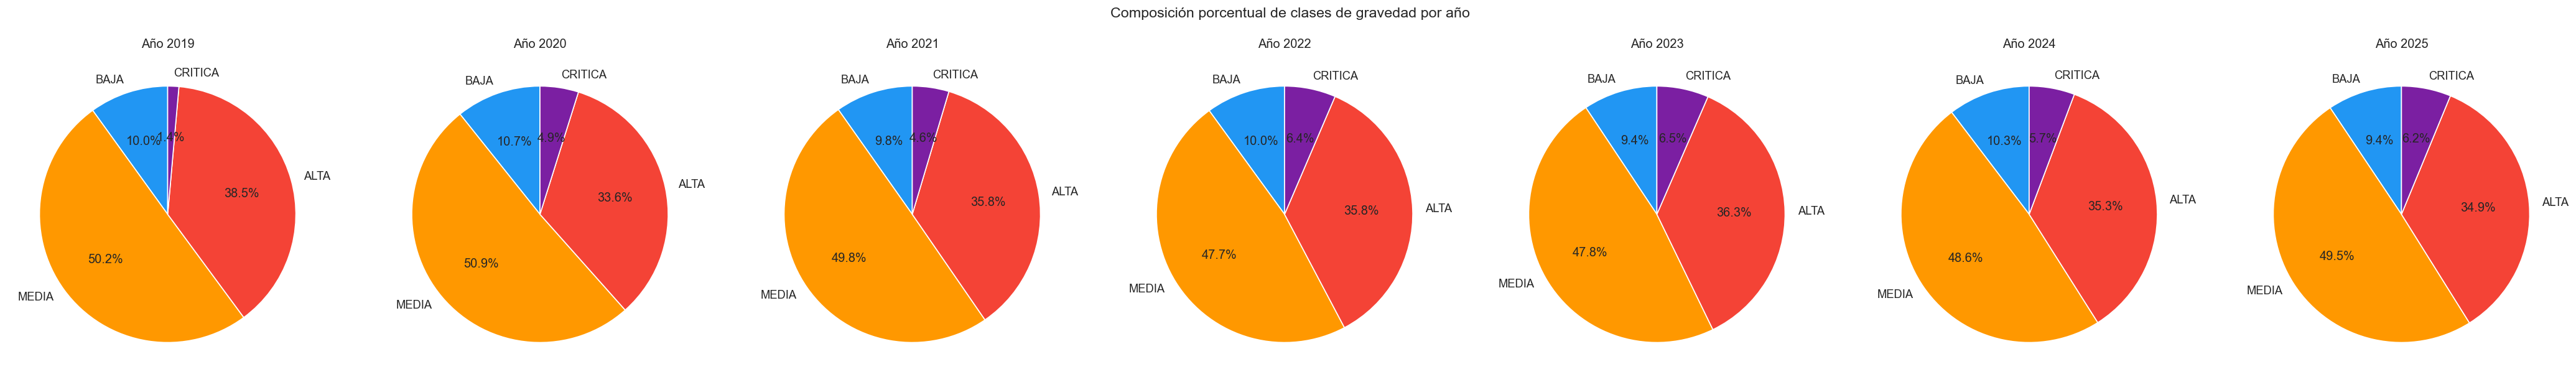


Tabla: composición porcentual por año
gravedad  BAJA  MEDIA  ALTA  CRITICA
anio                                
2019      10.0   50.2  38.5      1.4
2020      10.7   50.9  33.6      4.9
2021       9.8   49.8  35.8      4.6
2022      10.0   47.7  35.8      6.4
2023       9.4   47.8  36.3      6.5
2024      10.3   48.6  35.3      5.7
2025       9.4   49.5  34.9      6.2


In [14]:
pivot_pct = (
    df.groupby(["anio", "gravedad"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=orden_clases)
)
pivot_pct = pivot_pct.div(pivot_pct.sum(axis=1), axis=0) * 100

# Crear subplots de pastel por año
num_anos = len(pivot_pct)
fig, axes = plt.subplots(1, num_anos, figsize=(5*num_anos, 5))
if num_anos == 1:
    axes = [axes]

for idx, (año, row) in enumerate(pivot_pct.iterrows()):
    ax = axes[idx]
    ax.pie(row, labels=row.index, autopct='%1.1f%%', colors=colores_clases, startangle=90)
    ax.set_title(f"Año {int(año)}")

plt.suptitle("Composición porcentual de clases de gravedad por año", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nTabla: composición porcentual por año")
print(pivot_pct.round(1).to_string())

---
## 4. Selección de features para el modelo

In [15]:
FEATURES = [
    # Temporales
    'anio',
    'mes',
    'dia_semana',
    'es_fin_de_semana',
    'hora',
    # Espaciales
    'codigo_distrito',
    'codigo_circuito',
    'codigo_subcircuito',
    'freq_subcircuito',   # <-- reemplaza freq_sub_cuartil
    # Delito y contexto
    'codigo_iccs',
    'macro_lugar',
    'flag_coord',
]

TARGET = 'gravedad'

faltantes = [f for f in FEATURES if f not in df.columns]
if faltantes:
    print(f"ADVERTENCIA — columnas no encontradas: {faltantes}")
else:
    print(f"OK — {len(FEATURES)} features disponibles")

df_modelo = df[FEATURES + [TARGET]].dropna(subset=[TARGET])
print(f"Registros para modelado: {len(df_modelo):,}")

OK — 12 features disponibles
Registros para modelado: 76,860


In [16]:
# Codificación de variables categóricas con Label Encoding
# (compatible con XGBoost, RF y LightGBM sin matrices dispersas)
from sklearn.preprocessing import LabelEncoder

COLS_CATEGORICAS = ["codigo_distrito", "codigo_circuito", "codigo_subcircuito",
                    "codigo_iccs", "macro_lugar", "flag_coord"]

encoders = {}
for col in COLS_CATEGORICAS:
    le = LabelEncoder()
    df_modelo = df_modelo.copy()
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    encoders[col] = le

# Codificar el target con mapeo ORDINAL explícito (no alfabético)
MAPA_GRAVEDAD     = {"BAJA": 0, "MEDIA": 1, "ALTA": 2, "CRITICA": 3}
MAPA_GRAVEDAD_INV = {v: k for k, v in MAPA_GRAVEDAD.items()}

df_modelo[TARGET] = df_modelo[TARGET].astype(str).map(MAPA_GRAVEDAD)

print("Clases del target codificadas (orden ordinal):")
for cls, cod in MAPA_GRAVEDAD.items():
    print(f"  {cod} = {cls}")

print(f"\nDistribución del target codificado:")
print(df_modelo[TARGET].value_counts().sort_index())

Clases del target codificadas (orden ordinal):
  0 = BAJA
  1 = MEDIA
  2 = ALTA
  3 = CRITICA

Distribución del target codificado:
gravedad
0     7641
1    37858
2    27494
3     3867
Name: count, dtype: int64


---
## 5. Partición train / test (80/20 estratificada)

In [17]:
X = df_modelo[FEATURES]
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train):,} registros")
print(f"Test  : {len(X_test):,} registros")
print("\nDistribución de clases en train:")
print(y_train.value_counts().sort_index())
print("\nDistribución de clases en test:")
print(y_test.value_counts().sort_index())

Train : 61,488 registros
Test  : 15,372 registros

Distribución de clases en train:
gravedad
0     6113
1    30286
2    21995
3     3094
Name: count, dtype: int64

Distribución de clases en test:
gravedad
0    1528
1    7572
2    5499
3     773
Name: count, dtype: int64


---
## 6. Balanceo de clases en el conjunto de entrenamiento

Se aplica SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento. El conjunto de test **no se modifica** para que la evaluación refleje la distribución real del problema.

In [18]:
print("Distribución ANTES del balanceo:")
print(sorted(Counter(y_train).items()))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribución DESPUÉS del balanceo (SMOTE):")
print(sorted(Counter(y_train_bal).items()))
print(f"\nRegistros de entrenamiento balanceados: {len(X_train_bal):,}")

Distribución ANTES del balanceo:
[(0, 6113), (1, 30286), (2, 21995), (3, 3094)]

Distribución DESPUÉS del balanceo (SMOTE):
[(0, 30286), (1, 30286), (2, 30286), (3, 30286)]

Registros de entrenamiento balanceados: 121,144


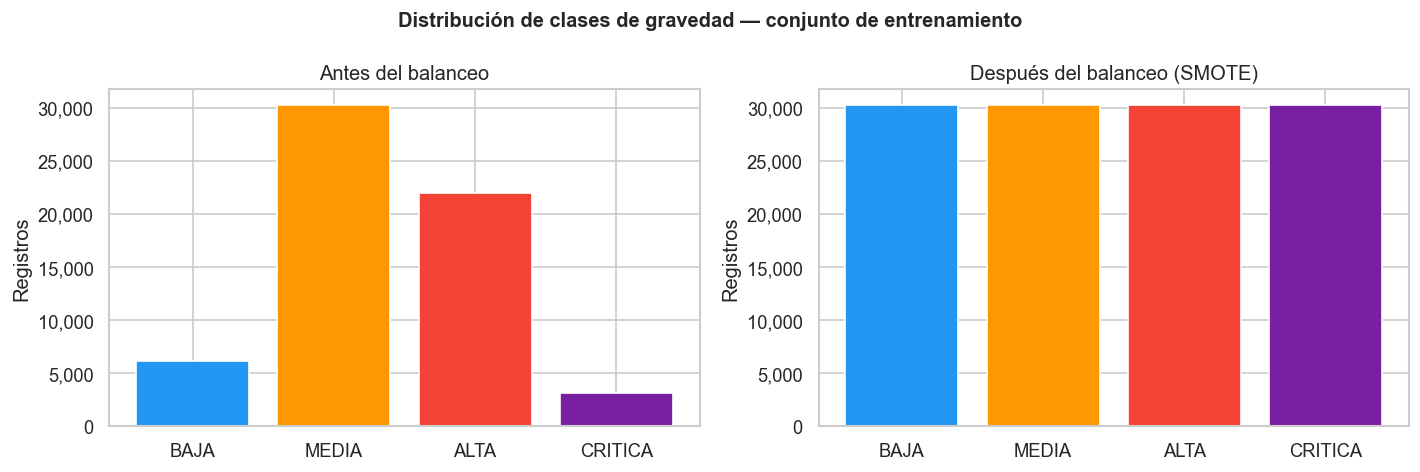

In [19]:
# ── Visualización comparativa antes/después del balanceo ──────
clase_nombre   = MAPA_GRAVEDAD_INV  # {0:BAJA, 1:MEDIA, 2:ALTA, 3:CRITICA}
color_por_clase = {
    "ALTA":    "#F44336",
    "BAJA":    "#2196F3",
    "CRITICA": "#7B1FA2",
    "MEDIA":   "#FF9800",
}

orden_logico  = ["BAJA", "MEDIA", "ALTA", "CRITICA"]
codigos       = [MAPA_GRAVEDAD[c] for c in orden_logico]
colores_orden = [color_por_clase[c] for c in orden_logico]

cnt_antes   = Counter(y_train)
cnt_despues = Counter(y_train_bal)

vals_antes   = [cnt_antes.get(c, 0)   for c in codigos]
vals_despues = [cnt_despues.get(c, 0) for c in codigos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(orden_logico, vals_antes,   color=colores_orden)
ax1.set_title("Antes del balanceo")
ax1.set_ylabel("Registros")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2.bar(orden_logico, vals_despues, color=colores_orden)
ax2.set_title("Después del balanceo (SMOTE)")
ax2.set_ylabel("Registros")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Distribución de clases de gravedad — conjunto de entrenamiento",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Exportación de archivos finales

In [20]:
# Dataset completo con todas las variables derivadas
df.to_csv(ARCHIVO_FINAL, sep=";", encoding="utf-8-sig", index=False)
print(f"Guardado: {ARCHIVO_FINAL}")

# Train y test sin balancear (para análisis y referencia)
train_df = X_train.copy()
train_df[TARGET] = y_train.values
train_df.to_csv(ARCHIVO_TRAIN, sep=";", encoding="utf-8-sig", index=False)
print(f"Guardado: {ARCHIVO_TRAIN}")

test_df = X_test.copy()
test_df[TARGET] = y_test.values
test_df.to_csv(ARCHIVO_TEST, sep=";", encoding="utf-8-sig", index=False)
print(f"Guardado: {ARCHIVO_TEST}")

# Train balanceado (para entrenar los modelos)
train_bal_df = pd.DataFrame(X_train_bal, columns=FEATURES)
train_bal_df[TARGET] = y_train_bal
train_bal_df.to_csv(ARCHIVO_BALANCE, sep=";", encoding="utf-8-sig", index=False)
print(f"Guardado: {ARCHIVO_BALANCE}")

print("\n=" * 40)
print("RESUMEN FINAL")
print("=" * 40)
print(f"Dataset completo     : {len(df):,} registros")
print(f"Train (sin balancear): {len(X_train):,} registros")
print(f"Train (balanceado)   : {len(X_train_bal):,} registros")
print(f"Test                 : {len(X_test):,} registros")
print(f"Features             : {len(FEATURES)}")
print(f"Clases de gravedad   : {list(MAPA_GRAVEDAD.keys())} → 0=BAJA 1=MEDIA 2=ALTA 3=CRITICA")

Guardado: C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_dataset_final.csv
Guardado: C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_train.csv
Guardado: C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_test.csv
Guardado: C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_train_balanceado.csv

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
RESUMEN FINAL
Dataset completo     : 76,860 registros
Train (sin balancear): 61,488 registros
Train (balanceado)   : 121,144 registros
Test                 : 15,372 registros
Features             : 12
Clases de gravedad   : ['BAJA', 'MEDIA', 'ALTA', 'CRITICA'] → 0=BAJA 1=MEDIA 2=ALTA 3=CRITICA
